<a href="https://colab.research.google.com/github/Lalithnise/Certificates/blob/main/python_package/notebook/example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone --depth 1 https://github.com/Hzzone/MTLFace.git
!mv MTLFace/python_package/* .
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image
import torch
import os.path as osp
torch.cuda.set_device(0)
import torch.nn.functional as F
from PIL import Image
from mtlface.modules import MTLFace
torch.autograd.set_grad_enabled(False)

Cloning into 'MTLFace'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 55 (delta 2), reused 45 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 3.37 MiB | 7.32 MiB/s, done.
Resolving deltas: 100% (2/2), done.


torch.autograd.grad_mode.set_grad_enabled(mode=False)

pretrained model
https://drive.google.com/file/d/1OmfAjP3BAqVxaQ2pwyJuOYUHy_incMNd/view?usp=share_link
https://pan.baidu.com/s/1GT95OPNR-7GQPMSFFVqzeQ?pwd=wizs

In [2]:
!pip install -U --no-cache-dir gdown --pre
!gdown --id 1OmfAjP3BAqVxaQ2pwyJuOYUHy_incMNd -O mtlface_checkpoints.tar

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1OmfAjP3BAqVxaQ2pwyJuOYUHy_incMNd
From (redirected): https://drive.google.com/uc?id=1OmfAjP3BAqVxaQ2pwyJuOYUHy_incMNd&confirm=t&uuid=60bfc56b-bd03-4933-a86e-80333944418a
To: /content/mtlface_checkpoints.tar
100% 1.09G/1.09G [00:12<00:00, 89.8MB/s]


In [27]:
!unzip mtlface_checkpoints.tar -d weights/


Archive:  mtlface_checkpoints.tar
 extracting: weights/archive/data.pkl  
 extracting: weights/archive/data/0  
 extracting: weights/archive/data/1  
 extracting: weights/archive/data/10  
 extracting: weights/archive/data/100  
 extracting: weights/archive/data/101  
 extracting: weights/archive/data/102  
 extracting: weights/archive/data/103  
 extracting: weights/archive/data/104  
 extracting: weights/archive/data/105  
 extracting: weights/archive/data/106  
 extracting: weights/archive/data/107  
 extracting: weights/archive/data/108  
 extracting: weights/archive/data/109  
 extracting: weights/archive/data/11  
 extracting: weights/archive/data/110  
 extracting: weights/archive/data/111  
 extracting: weights/archive/data/112  
 extracting: weights/archive/data/113  
 extracting: weights/archive/data/114  
 extracting: weights/archive/data/115  
 extracting: weights/archive/data/116  
 extracting: weights/archive/data/117  
 extracting: weights/archive/data/118  
 extracting:

In [28]:
!pip install Ninja
!echo "from mtlface.stylegan2.op import upfirdn2d, FusedLeakyReLU, fused_leaky_relu" > colab_init.py
!python colab_init.py

W0922 07:55:06.469000 10028 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0922 07:55:06.469000 10028 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
ninja: no work to do.
W0922 07:55:06.509000 10028 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0922 07:55:06.509000 10028 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
ninja: no work to do.


# Face Alignment

In [29]:
# !pip install dlib
from mtlface.face_aligment import face_process

Saving im1.jpg to im1 (1).jpg


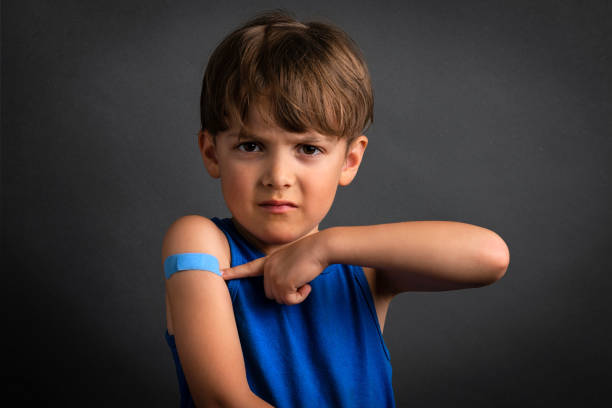

In [30]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]   # use the uploaded file
Image.open(img_path)

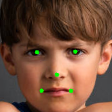

In [31]:
face_process(img_path, plot=True)

-----

In [32]:
mtlface = MTLFace().cuda().eval()
mtlface.load_state_dict(torch.load('mtlface_checkpoints.tar'))

<All keys matched successfully>

In [37]:
from PIL import Image
from torchvision import transforms
import torch
import os.path as osp

# Path to your uploaded image
img_path = "im1.jpg"   # since you uploaded im1.jpg

# Open + preprocess
input_img = Image.open(img_path).convert("RGB")
transform = transforms.Compose([
    transforms.Resize((112, 112)),  # force square resize
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5], inplace=True),
])

images = transform(input_img).unsqueeze(0).cuda()
print(images.shape)  # should show [1, 3, 112, 112]


torch.Size([1, 3, 112, 112])


In [38]:
x_vec, x_age = mtlface.encode(images)

# Face Recognition

In [41]:
print("Embedding vector length:", len(x_vec[0]))
print("Predicted Age:", x_age.item())
 # cosine similarity

Embedding vector length: 512
Predicted Age: 27.792661666870117


# Age Estimation

In [42]:
x_age

tensor([27.7927], device='cuda:0')

# Face Age Synthesis

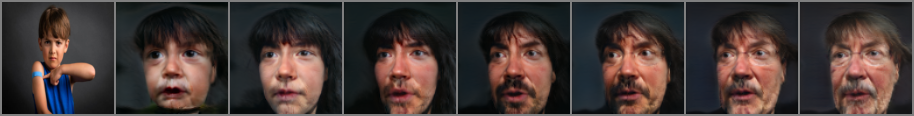

In [43]:
bs = images.size(0)
target_labels = torch.arange(7).cuda().unsqueeze(1).repeat(bs, 1).flatten()
repeat_images = images.unsqueeze(1).repeat(1, 7, 1, 1, 1).view(-1, 3, 112, 112)
outputs = mtlface.aging(repeat_images, target_labels).view(bs, 7, 3, 112, 112)
outputs = torch.cat([images.unsqueeze(1), outputs], dim=1).view(-1, 3, 112, 112)
to_pil_image(make_grid(outputs) * 0.5 + 0.5)

In [34]:
!ls -lh weights/archive/


total 176K
drwxr-xr-x 2 root root  20K Sep 22 07:54 data
-rw-r--r-- 1 root root 149K Dec 31  1979 data.pkl
-rw-r--r-- 1 root root    2 Dec 31  1979 version
